# EDA — Titanic

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(train.shape)
train.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Общий обзор — пропуски и типы

Смотрим, где пропуски и сколько их. Это сразу подскажет, с чем придётся работать.

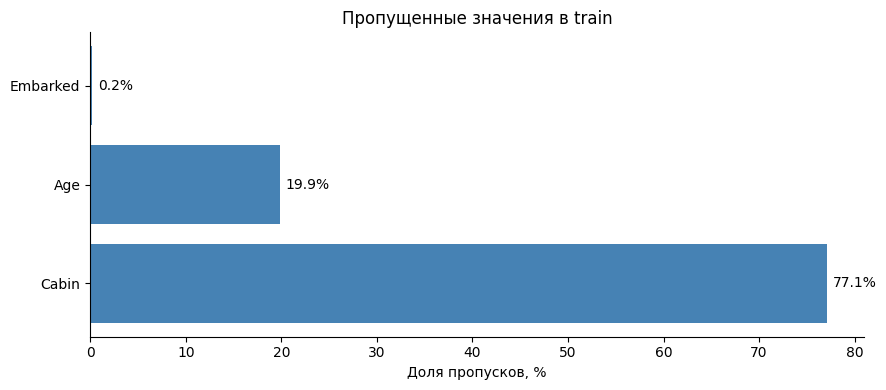


Вывод: Cabin почти полностью пуста (77%), Age пропущен у ~20%, Embarked — единицы.


In [2]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
pct = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.barh(missing.index, pct.values, color='steelblue')
ax.bar_label(bars, labels=[f'{v}%' for v in pct.values], padding=4)
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Пропущенные значения в train')
plt.tight_layout()
plt.show()

print('\nВывод: Cabin почти полностью пуста (77%), Age пропущен у ~20%, Embarked — единицы.')

## 2. Целевая переменная — Survived

Смотрим на баланс классов. Если классы сильно несбалансированы — это влияет на выбор метрики.

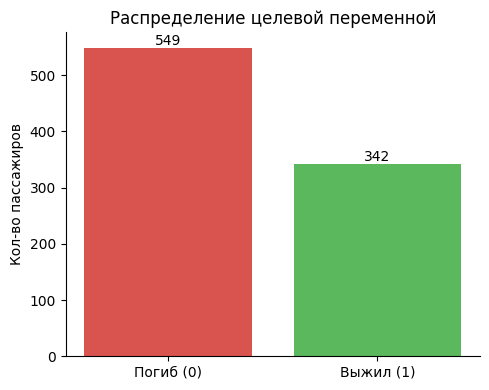

Выживаемость: 38.4%
Вывод: Классы немного несбалансированы (~38% выживших), но некритично — accuracy ещё информативна.


In [3]:
counts = train['Survived'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Погиб (0)', 'Выжил (1)'], counts.values, color=['#d9534f', '#5cb85c'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center')
ax.set_title('Распределение целевой переменной')
ax.set_ylabel('Кол-во пассажиров')
plt.tight_layout()
plt.show()

print(f'Выживаемость: {counts[1]/len(train)*100:.1f}%')
print('Вывод: Классы немного несбалансированы (~38% выживших), но некритично — accuracy ещё информативна.')

## 3. Пол (Sex) → кодируем male=0, female=1

Смотрим, насколько пол вообще предсказывает выживаемость. Если разница огромная — фича нужна.

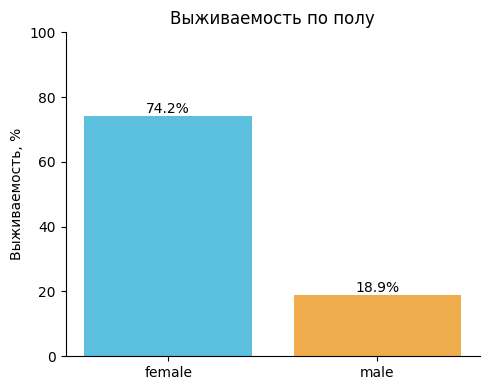

Вывод: Женщины выживали в ~3.5 раза чаще мужчин — пол самая сильная одиночная фича.


In [4]:
surv_by_sex = train.groupby('Sex')['Survived'].mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(surv_by_sex.index, surv_by_sex.values * 100, color=['#5bc0de', '#f0ad4e'])
for i, (_, v) in enumerate(surv_by_sex.items()):
    ax.text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
ax.set_ylabel('Выживаемость, %')
ax.set_title('Выживаемость по полу')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print('Вывод: Женщины выживали в ~3.5 раза чаще мужчин — пол самая сильная одиночная фича.')

## 4. Класс каюты (Pclass)

Смотрим выживаемость по классам. Это объяснит, почему мы позже создаём фичи WomanHighClass и ManThirdClass.

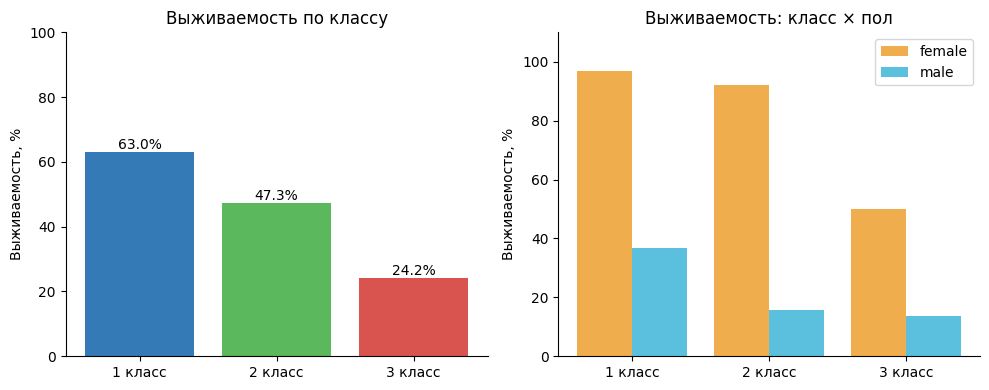

Вывод: Женщины 1-2 класса выжили почти все. Мужчины 3 класса — меньше всех.
→ Добавляем бинарные фичи WomanHighClass и ManThirdClass, они лучше захватывают эту нелинейность.


In [5]:
surv_by_class = train.groupby('Pclass')['Survived'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([f'{c} класс' for c in surv_by_class.index], surv_by_class.values * 100,
            color=['#337ab7', '#5cb85c', '#d9534f'])
for i, v in enumerate(surv_by_class.values):
    axes[0].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
axes[0].set_ylabel('Выживаемость, %')
axes[0].set_title('Выживаемость по классу')
axes[0].set_ylim(0, 100)

pivot = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
x = np.arange(3)
axes[1].bar(x - 0.2, pivot['female'] * 100, width=0.4, label='female', color='#f0ad4e')
axes[1].bar(x + 0.2, pivot['male']   * 100, width=0.4, label='male',   color='#5bc0de')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['1 класс', '2 класс', '3 класс'])
axes[1].set_ylabel('Выживаемость, %')
axes[1].set_title('Выживаемость: класс × пол')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Вывод: Женщины 1-2 класса выжили почти все. Мужчины 3 класса — меньше всех.')
print('→ Добавляем бинарные фичи WomanHighClass и ManThirdClass, они лучше захватывают эту нелинейность.')

## 5. Возраст (Age) → заполняем медианой, создаём AgeGroup

Смотрим распределение возраста и его связь с выживаемостью — чтобы понять, нужна ли дискретизация.

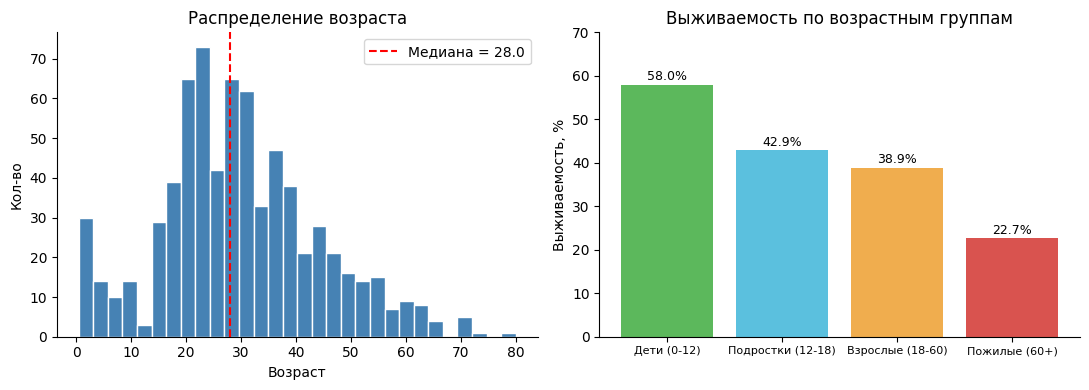

Пропусков в Age: 177 (19.9%)
Вывод: Дети выживали чаще взрослых и пожилых — дискретизация на группы осмыслена.
Заполняем пропуски медианой (а не средним) — распределение немного скошено вправо.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(train['Age'].median(), color='red', linestyle='--', label=f'Медиана = {train["Age"].median()}')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Кол-во')
axes[0].set_title('Распределение возраста')
axes[0].legend()

bins = [0, 12, 18, 60, 100]
labels = ['Дети (0-12)', 'Подростки (12-18)', 'Взрослые (18-60)', 'Пожилые (60+)']
train['AgeGroup_tmp'] = pd.cut(train['Age'], bins=bins, labels=labels)
surv_ag = train.groupby('AgeGroup_tmp', observed=True)['Survived'].mean()

axes[1].bar(surv_ag.index, surv_ag.values * 100, color=['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f'])
for i, v in enumerate(surv_ag.values):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)
axes[1].set_ylabel('Выживаемость, %')
axes[1].set_title('Выживаемость по возрастным группам')
axes[1].set_ylim(0, 70)
axes[1].tick_params(axis='x', labelsize=8)

train.drop(columns=['AgeGroup_tmp'], inplace=True)

plt.tight_layout()
plt.show()

print(f'Пропусков в Age: {train["Age"].isnull().sum()} ({train["Age"].isnull().mean()*100:.1f}%)')
print('Вывод: Дети выживали чаще взрослых и пожилых — дискретизация на группы осмыслена.')
print('Заполняем пропуски медианой (а не средним) — распределение немного скошено вправо.')

## 6. Тариф (Fare) → заполняем медианой, создаём FarePerPerson

Fare сильно скошен и напрямую связан с классом. Смотрим, стоит ли нормировать на размер семьи.

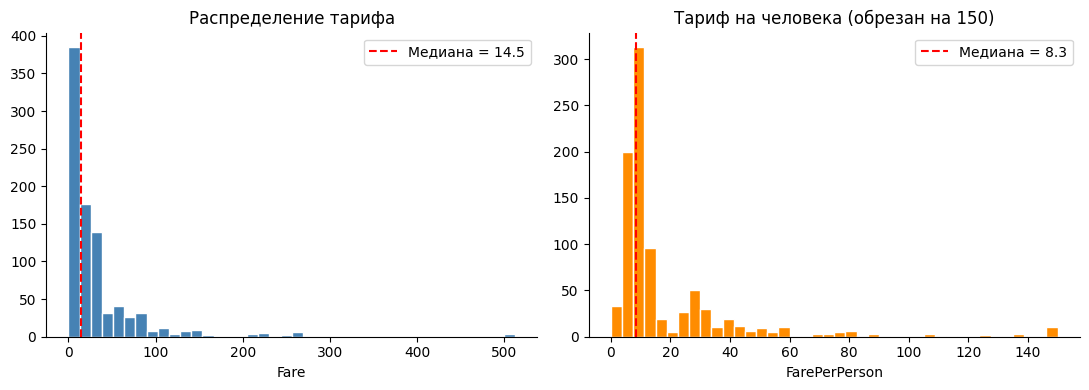

Вывод: Fare очень скошен (хвост вправо). Одна семья платила один билет на всех,
поэтому FarePerPerson = Fare / FamilySize — честнее отражает реальную стоимость места.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train['Fare'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(train['Fare'].median(), color='red', linestyle='--',
                label=f'Медиана = {train["Fare"].median():.1f}')
axes[0].set_xlabel('Fare')
axes[0].set_title('Распределение тарифа')
axes[0].legend()

family_size = train['SibSp'] + train['Parch'] + 1
fare_per_person = train['Fare'] / family_size

axes[1].hist(fare_per_person.dropna().clip(upper=150), bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(fare_per_person.median(), color='red', linestyle='--',
                label=f'Медиана = {fare_per_person.median():.1f}')
axes[1].set_xlabel('FarePerPerson')
axes[1].set_title('Тариф на человека (обрезан на 150)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Вывод: Fare очень скошен (хвост вправо). Одна семья платила один билет на всех,')
print('поэтому FarePerPerson = Fare / FamilySize — честнее отражает реальную стоимость места.')

## 7. Размер семьи (FamilySize) и признак Alone

Складываем SibSp + Parch + 1. Смотрим, как размер семьи влияет на выживаемость.

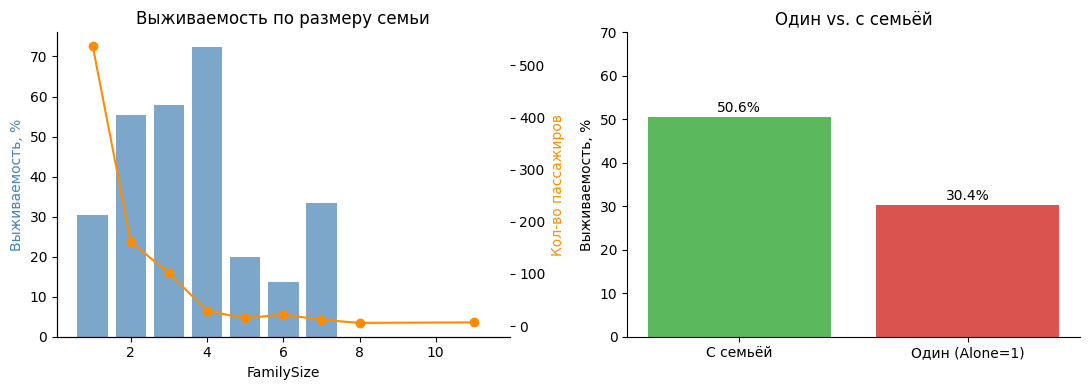

Вывод: Одиночки выживали реже. Очень большие семьи (7+) тоже хуже — сложнее эвакуироваться.
Бинарный флаг Alone улавливает самый важный порог (1 vs. > 1).


In [8]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

surv_fs = train.groupby('FamilySize')['Survived'].mean()
counts_fs = train['FamilySize'].value_counts().sort_index()

ax2 = axes[0].twinx()
axes[0].bar(surv_fs.index, surv_fs.values * 100, color='steelblue', alpha=0.7, label='Выживаемость')
ax2.plot(counts_fs.index, counts_fs.values, 'o-', color='darkorange', label='Кол-во')
axes[0].set_xlabel('FamilySize')
axes[0].set_ylabel('Выживаемость, %', color='steelblue')
ax2.set_ylabel('Кол-во пассажиров', color='darkorange')
axes[0].set_title('Выживаемость по размеру семьи')

alone_surv = train.groupby(train['FamilySize'] == 1)['Survived'].mean()
axes[1].bar(['С семьёй', 'Один (Alone=1)'],
            [alone_surv[False] * 100, alone_surv[True] * 100],
            color=['#5cb85c', '#d9534f'])
for i, v in enumerate([alone_surv[False], alone_surv[True]]):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
axes[1].set_ylabel('Выживаемость, %')
axes[1].set_title('Один vs. с семьёй')
axes[1].set_ylim(0, 70)

train.drop(columns=['FamilySize'], inplace=True)

plt.tight_layout()
plt.show()

print('Вывод: Одиночки выживали реже. Очень большие семьи (7+) тоже хуже — сложнее эвакуироваться.')
print('Бинарный флаг Alone улавливает самый важный порог (1 vs. > 1).')

## 8. Имя → Initial (звание)

В имени зашито звание (Mr., Mrs., Miss., Master. и т.д.). Это proxy для пола, возраста и класса одновременно.

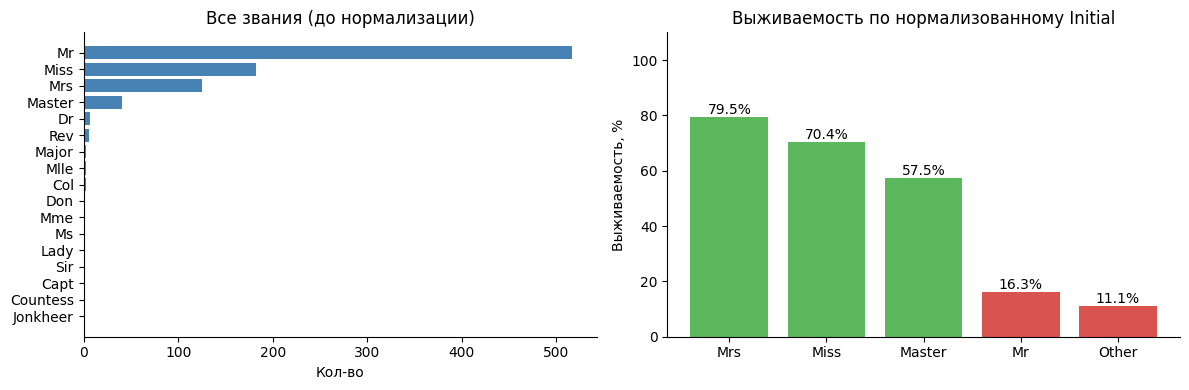

Вывод: Редкие звания объединяем в 5 групп. Mrs и Miss выживали значительно чаще Mr.
Master (мальчики) тоже выживали часто — детей спасали в первую очередь.


In [9]:
train['Initial_raw'] = train['Name'].str.extract(r'([A-Za-z]+)\.')
initial_counts = train['Initial_raw'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(initial_counts.index, initial_counts.values, color='steelblue')
axes[0].set_xlabel('Кол-во')
axes[0].set_title('Все звания (до нормализации)')
axes[0].invert_yaxis()

mapping = {
    'Mlle': 'Miss', 'Mme': 'Miss', 'Ms': 'Miss',
    'Dr': 'Mr', 'Major': 'Mr', 'Capt': 'Mr', 'Sir': 'Mr', 'Don': 'Mr',
    'Lady': 'Mrs', 'Countess': 'Mrs', 'Dona': 'Mrs',
    'Jonkheer': 'Other', 'Col': 'Other', 'Rev': 'Other'
}
train['Initial_norm'] = train['Initial_raw'].replace(mapping)

surv_init = train.groupby('Initial_norm')['Survived'].mean().sort_values(ascending=False)
colors = ['#5cb85c' if v > 0.5 else '#d9534f' for v in surv_init.values]
axes[1].bar(surv_init.index, surv_init.values * 100, color=colors)
for i, v in enumerate(surv_init.values):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
axes[1].set_ylabel('Выживаемость, %')
axes[1].set_title('Выживаемость по нормализованному Initial')
axes[1].set_ylim(0, 110)

train.drop(columns=['Initial_raw', 'Initial_norm'], inplace=True)

plt.tight_layout()
plt.show()

print('Вывод: Редкие звания объединяем в 5 групп. Mrs и Miss выживали значительно чаще Mr.')
print('Master (мальчики) тоже выживали часто — детей спасали в первую очередь.')

## 9. Каюта (Cabin) → Deck

77% значений Cabin пропущено, но первая буква — это палуба. Смотрим, даёт ли палуба сигнал.

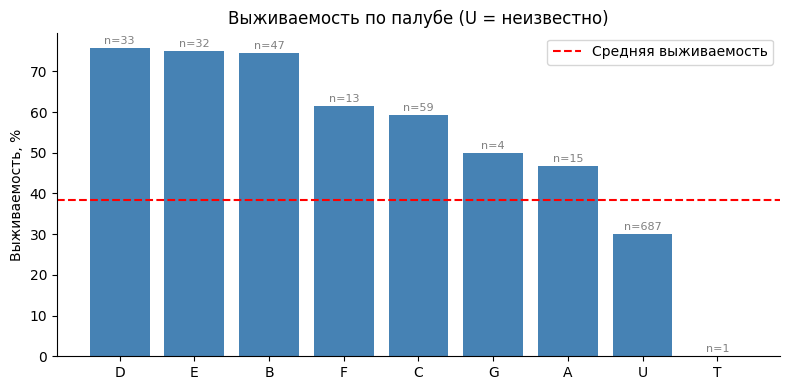

Вывод: Палубы B, C, D, E — высокая выживаемость (верхние палубы, 1-й класс).
U (Unknown) — огромная группа с низкой выживаемостью. Палуба несёт сигнал — оставляем.


In [10]:
train['Deck'] = train['Cabin'].fillna('U0').str.extract(r'([A-Za-z])')

surv_deck = train.groupby('Deck')['Survived'].mean().sort_values(ascending=False)
cnt_deck  = train.groupby('Deck')['Survived'].count()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(surv_deck.index, surv_deck.values * 100, color='steelblue')
for bar, deck in zip(bars, surv_deck.index):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'n={cnt_deck[deck]}', ha='center', fontsize=8, color='gray')
ax.axhline(train['Survived'].mean() * 100, linestyle='--', color='red', label='Средняя выживаемость')
ax.set_ylabel('Выживаемость, %')
ax.set_title('Выживаемость по палубе (U = неизвестно)')
ax.legend()
plt.tight_layout()
plt.show()

train.drop(columns=['Deck'], inplace=True)

print('Вывод: Палубы B, C, D, E — высокая выживаемость (верхние палубы, 1-й класс).')
print('U (Unknown) — огромная группа с низкой выживаемостью. Палуба несёт сигнал — оставляем.')

## 10. Порт посадки (Embarked) → заполняем 'S'

Два пропуска в Embarked. Смотрим распределение по портам — чем заполнять пропуски?

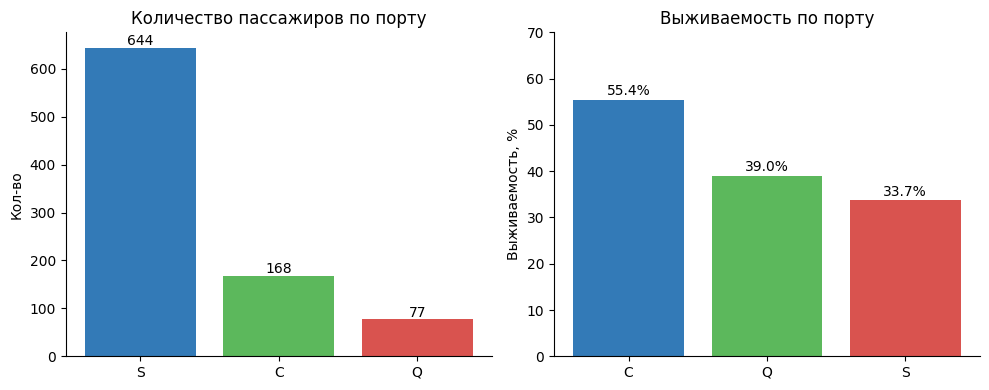

Пропусков в Embarked: 2
Вывод: Southampton — самый частый порт (72%). Заполняем 2 пропуска модой = S.
Cherbourg немного лучше по выживаемости — там садилось больше пассажиров 1-го класса.


In [11]:
emb_counts = train['Embarked'].value_counts()
surv_emb   = train.groupby('Embarked')['Survived'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(emb_counts.index, emb_counts.values, color=['#337ab7', '#5cb85c', '#d9534f'])
for i, (port, v) in enumerate(emb_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center')
axes[0].set_title('Количество пассажиров по порту')
axes[0].set_ylabel('Кол-во')

axes[1].bar(surv_emb.index, surv_emb.values * 100, color=['#337ab7', '#5cb85c', '#d9534f'])
for i, v in enumerate(surv_emb.values):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center')
axes[1].set_title('Выживаемость по порту')
axes[1].set_ylabel('Выживаемость, %')
axes[1].set_ylim(0, 70)

plt.tight_layout()
plt.show()

print(f'Пропусков в Embarked: {train["Embarked"].isnull().sum()}')
print('Вывод: Southampton — самый частый порт (72%). Заполняем 2 пропуска модой = S.')
print('Cherbourg немного лучше по выживаемости — там садилось больше пассажиров 1-го класса.')

## 11. Взаимодействие Sex × Pclass → WomanHighClass и ManThirdClass

Убеждаемся, что именно эти два сочетания — экстремальные случаи, которые стоит выделить отдельно.

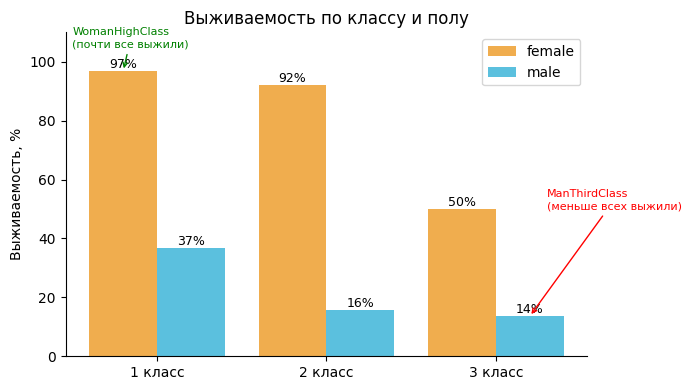

Вывод: Женщины 1-2 класса — ~93% и ~92% выживаемости. Мужчины 3 класса — ~15%.
Два бинарных флага позволяют модели явно захватить эти экстремумы без кросс-произведения.


In [12]:
pivot = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
ax.bar(x - 0.2, pivot['female'], width=0.4, label='female', color='#f0ad4e')
ax.bar(x + 0.2, pivot['male'],   width=0.4, label='male',   color='#5bc0de')

for i, v in enumerate(pivot['female']):
    ax.text(i - 0.2, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
for i, v in enumerate(pivot['male']):
    ax.text(i + 0.2, v + 1, f'{v:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['1 класс', '2 класс', '3 класс'])
ax.set_ylabel('Выживаемость, %')
ax.set_title('Выживаемость по классу и полу')
ax.set_ylim(0, 110)
ax.legend()

ax.annotate('WomanHighClass\n(почти все выжили)', xy=(0 - 0.2, pivot['female'].iloc[0]),
            xytext=(-0.5, 105), fontsize=8, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate('ManThirdClass\n(меньше всех выжили)', xy=(2 + 0.2, pivot['male'].iloc[2]),
            xytext=(2.3, 50), fontsize=8, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print('Вывод: Женщины 1-2 класса — ~93% и ~92% выживаемости. Мужчины 3 класса — ~15%.')
print('Два бинарных флага позволяют модели явно захватить эти экстремумы без кросс-произведения.')

## 12. Корреляционная матрица после preprocessing

Смотрим итоговые корреляции всех фич с Survived — убеждаемся, что добавленные признаки несут сигнал.

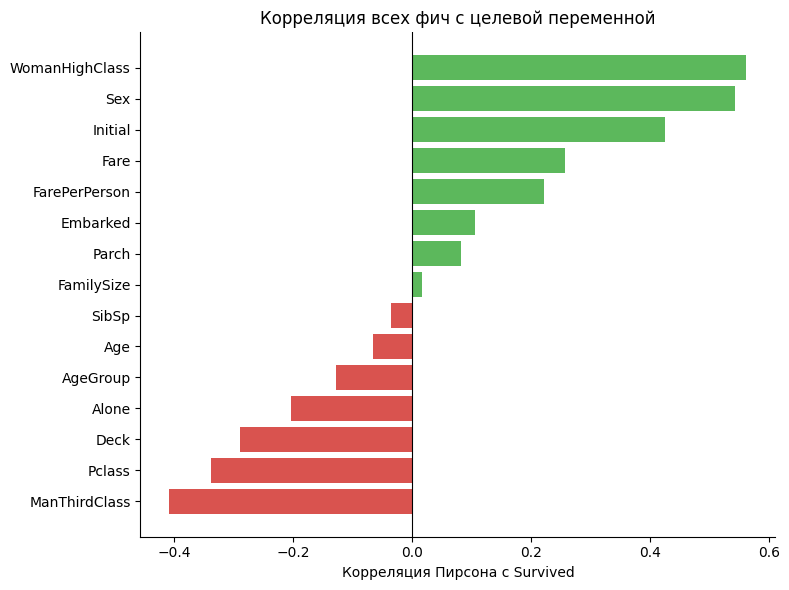

Вывод: WomanHighClass и Sex — самые сильные положительные сигналы.
ManThirdClass — самый сильный отрицательный сигнал.
FarePerPerson, Initial, Pclass — тоже значимы. Deck и Alone несут умеренный сигнал.


In [13]:
import sys
sys.path.insert(0, '.')
from preprocessing import preprocessing

train_raw = pd.read_csv('data/train.csv')
test_raw  = pd.read_csv('data/test.csv')

target = train_raw['Survived'].copy()
X_train, _ = preprocessing(train_raw.copy(), test_raw.copy())

X_train['Survived'] = target.values
corr = X_train.corr()['Survived'].drop('Survived').sort_values()

colors = ['#d9534f' if v < 0 else '#5cb85c' for v in corr.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Корреляция Пирсона с Survived')
ax.set_title('Корреляция всех фич с целевой переменной')
plt.tight_layout()
plt.show()

print('Вывод: WomanHighClass и Sex — самые сильные положительные сигналы.')
print('ManThirdClass — самый сильный отрицательный сигнал.')
print('FarePerPerson, Initial, Pclass — тоже значимы. Deck и Alone несут умеренный сигнал.')

## Итог

| Решение в preprocessing.py | Обоснование из EDA |
|---|---|
| `Age` → заполнить медианой | 20% пропусков, распределение скошено |
| `Age` → `AgeGroup` (4 бина) | Нелинейная зависимость: дети выживали чаще |
| `Cabin` → `Deck` + Unknown=U | 77% пропусков, но палуба несёт сигнал |
| `Embarked` → заполнить S | S — мода (72%), пропусков всего 2 |
| `Fare` → `FarePerPerson` | Семья платила один билет на всех |
| `FamilySize` + `Alone` | Одиночки выживали реже |
| `Name` → `Initial` (5 групп) | Звание — proxy пол+возраст+статус |
| `WomanHighClass`, `ManThirdClass` | Экстремальные комбинации Sex×Pclass |
| Дроп `Name`, `Ticket`, `Cabin`, `PassengerId` | Нет прямого сигнала после извлечения фич |